# 07 · Pricing

French motor policies, EUR per policy-year. Frequency GLMs are fitted on a 75% training split and scored on the other 25%. Severity comes from 01 and the capital loading from the 02 one-policy-year proxy. The loading is an illustrative assumption, not a Solvency II quantity.

In [1]:
import sys
from pathlib import Path
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / 'src' / 'project.py').is_file():
        project_root = parent
        break
else:
    raise RuntimeError('Run from the project root or from notebooks/.')
sys.path.insert(0, str(project_root / 'src'))
from project import DATA_DIR, RESULTS_DIR, result_path, setup, require_results, record_results
setup()
require_results('calibrated_model.json', 'loss_summary.json')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from insurance_model import clean_frequency, CalibratedModel, severity_mean, var, es
import pricing_model as pm

RNG_SEED = 42
EUR = lambda v: f"EUR {v:,.2f}"

model = CalibratedModel.from_json(result_path('calibrated_model.json'))
loss_summary = json.load(open(result_path('loss_summary.json')))
print("Loaded Notebook 01's calibrated model and Notebook 02's portfolio loss summary.")

Loaded Notebook 01's calibrated model and Notebook 02's portfolio loss summary.


## Rating inputs

Use the earlier exposure and claim-count rules. Vehicle age is capped at 30 and BonusMalus at 150 as additional modelling assumptions.

In [2]:
freq_raw = pd.read_csv(str(DATA_DIR / 'freMTPL2freq.csv'))
freq_clean, clean_report = clean_frequency(freq_raw)
freq_priced, pricing_report = pm.clean_for_pricing(freq_clean)
from insurance_model import frequency_cleaning_summary
print(frequency_cleaning_summary(clean_report))
print('Severity fields are not loaded here (severity is taken from 01 as a single mean); see 01 for that part of the cleaning report.')
print(pricing_report)

{'n_policies': 678013, 'n_exposure_capped': 1224, 'exposure_max_before': 2.01, 'n_claimnb_capped': 9, 'claimnb_max_before': 16, 'total_claims_freq_table': 36056.0}
Severity fields are not loaded here (severity is taken from 01 as a single mean); see 01 for that part of the cleaning report.
PricingCleaningReport(n_policies=678013, n_vehage_capped=1116, vehage_max_before=100, n_bonusmalus_capped=209, bonusmalus_max_before=230)


Caps limit the influence of extreme covariates. Their sensitivity has not been tested.

## Frequency GLMs

Both models use log(exposure) as an offset. NB2 dispersion is estimated from the training Poisson residuals and then NB2 is fitted by IRLS, so it isn't a joint maximum-likelihood fit. In-sample fit and held-out diagnostics answer different questions.

In [3]:
train, test = pm.train_test_split_pricing(freq_priced, test_frac=0.25, seed=RNG_SEED)
print(f"Train: {len(train):,} policies   Test: {len(test):,} policies")

poisson_res = pm.fit_poisson_glm(train)
nb_res, alpha_hat = pm.fit_negbin_glm(train, poisson_results=poisson_res)

model_compare = pd.DataFrame({
    'Model': ['Poisson GLM (+ covariates)', 'NB2 GLM (+ covariates)'],
    'AIC': [poisson_res.aic, nb_res.aic + 2],
    'Log-likelihood': [poisson_res.llf, nb_res.llf],
    'Pearson dispersion (train)': [pm.pearson_dispersion(poisson_res), pm.pearson_dispersion(nb_res)],
})
model_compare

assert poisson_res.converged and nb_res.converged
assert set(train.IDpol).isdisjoint(set(test.IDpol))

Train: 508,510 policies   Test: 169,503 policies


NB2 is used for the pricing example. Held-out Poisson deviance is 0.3231 for both models against 0.3334 for a constant rate, and NB2 actual/predicted is 1.0119. NB2 AIC carries one extra parameter (the dispersion).

## Held-out evaluation

In [4]:
pred_test = pm.predict_annualized_frequency_negbin(nb_res, test)
cal_table = pm.calibration_table(test, pred_test, n_bins=10)
cal_table.round(4)

from sklearn.metrics import mean_poisson_deviance
pred_poisson = pm.predict_annualized_frequency_poisson(poisson_res, test)
base_rate = train.ClaimNb.sum() / train.Exposure.sum()
validation_rows = []
for label, rate in [('Constant', np.full(len(test), base_rate)), ('Poisson', pred_poisson), ('NB2', pred_test)]:
    count = rate * test.Exposure.to_numpy()
    validation_rows.append(dict(model=label, actual_to_predicted=test.ClaimNb.sum()/count.sum(),
                               poisson_deviance=mean_poisson_deviance(test.ClaimNb, count)))
validation = pd.DataFrame(validation_rows)
display(cal_table.round(4)); display(validation.round(4))

,decile,n_policies,total_exposure,actual_claims,predicted_claims,actual_rate,predicted_rate,pct_error
0,1,16951,"10,773.139",526,549.911,0.049,0.051,4.546
1,2,16950,"10,649.853",702,681.537,0.066,0.064,-2.915
2,3,16950,"10,518.478",795,770.706,0.076,0.073,-3.056
3,4,16950,"10,109.046",834,829.538,0.083,0.082,-0.535
4,5,16951,"9,591.695",879,872.653,0.092,0.091,-0.722
5,6,16950,"8,962.569",926,900.772,0.103,0.101,-2.724
6,7,16950,"8,141.646",893,907.748,0.110,0.112,1.651
7,8,16950,"7,363.199",996,921.530,0.135,0.125,-7.477
8,9,16950,"6,879.060",1110,"1,024.063",0.161,0.149,-7.742
9,10,16951,"6,503.459",1484,"1,579.265",0.228,0.243,6.420


,model,actual_to_predicted,poisson_deviance
0,Constant,1.021,0.333
1,Poisson,1.019,0.323
2,NB2,1.012,0.323


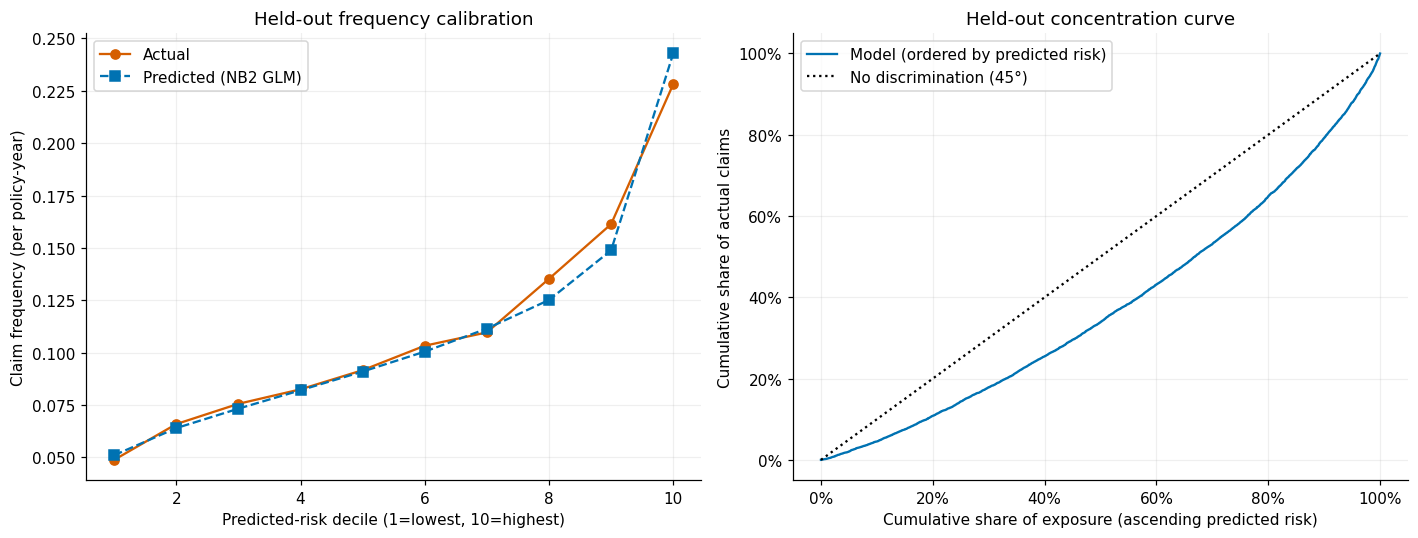

In [5]:
from matplotlib.ticker import PercentFormatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(cal_table['decile'], cal_table['actual_rate'], 'o-', label='Actual', color='C3')
axes[0].plot(cal_table['decile'], cal_table['predicted_rate'], 's--', label='Predicted (NB2 GLM)', color='C0')
axes[0].set_xlabel('Predicted-risk decile (1=lowest, 10=highest)'); axes[0].set_ylabel('Claim frequency (per policy-year)')
axes[0].set_title('Held-out frequency calibration')
axes[0].legend()

cum_exp, cum_claims = pm.gini_lift(test, pred_test)
axes[1].plot(cum_exp, cum_claims, color='C0', label='Model (ordered by predicted risk)')
axes[1].plot([0, 1], [0, 1], 'k:', label='No discrimination (45°)')
axes[1].set_xlabel('Cumulative share of exposure (ascending predicted risk)')
axes[1].set_ylabel('Cumulative share of actual claims')
axes[1].set_title('Held-out concentration curve')
axes[1].legend()

axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout(); plt.show()

A concentration curve below the diagonal means the model separates risks. Calibration (observed vs predicted counts) is a separate question from discrimination.

## Pure premium

Annualised predicted frequency times the common severity mean (EUR 2,901.56, from 01). Severity could be linked to covariates through IDpol but no severity GLM is fitted here. Severity and the risk load use the full sample, so there is no held-out claims-cost result. Exposure-weighted average pure premium on the test set is EUR 293.03.

In [6]:
sev_mean = severity_mean(model)
print(f"E[X] (portfolio-wide severity mean, from Notebook 01's model): {EUR(sev_mean)}")

pure_prem_test = pm.pure_premium(pred_test, sev_mean)
cal_table['pure_premium'] = pm.pure_premium(cal_table['predicted_rate'].to_numpy(), sev_mean)
print(f"Pure premium range across test-set policies: {EUR(pure_prem_test.min())} - {EUR(pure_prem_test.max())}")
print(f"Pure premium, exposure-weighted average: {EUR(np.average(pure_prem_test, weights=test.Exposure))}")
cal_table[['decile', 'predicted_rate', 'pure_premium']].round(2)

E[X] (portfolio-wide severity mean, from Notebook 01's model): EUR 2,901.56
Pure premium range across test-set policies: EUR 57.65 - EUR 3,885.82
Pure premium, exposure-weighted average: EUR 293.03


,decile,predicted_rate,pure_premium
0,1,0.050,148.110
1,2,0.060,185.690
2,3,0.070,212.600
3,4,0.080,238.100
4,5,0.090,263.980
5,6,0.100,291.620
6,7,0.110,323.510
7,8,0.130,363.140
8,9,0.150,431.950
9,10,0.240,704.600


## Gross premium

Gross premium = (pure premium + fixed expense + capital loading) / (1 − variable expense ratio − target profit margin).

Capital loading is k × K/E × pure premium, using the one-policy-year capital ratio from 02. The assumed k is neither a fitted cost of capital nor a diversified allocation or Solvency II Risk Margin.

In [7]:
portfolio_var995 = loss_summary['var_995']
portfolio_mean = loss_summary['analytical_mean_loss']
capital_ratio = (portfolio_var995 - portfolio_mean) / portfolio_mean
print(f"One-policy-year K_99.5 (Notebook 02) = {EUR(portfolio_var995 - portfolio_mean)}; "
      f"capital ratio (VaR99.5-mean)/mean = {capital_ratio:.2f}x")

ASSUMPTIONS = pm.PremiumAssumptions(
    fixed_expense=30.0,            # EUR per policy-year -- assumed
    variable_expense_ratio=0.15,   # 15% of gross premium -- assumed (commission + tax)
    target_profit_margin=0.05,     # 5% of gross premium -- assumed
    capital_loading_k=0.01,        # illustrative scaling constant, not estimated; sensitivity below
)

cal_table['capital_loading'] = pm.capital_loading_pro_rata(
    cal_table['pure_premium'].to_numpy(), portfolio_var995, portfolio_mean, ASSUMPTIONS.capital_loading_k)
cal_table['gross_premium'] = pm.gross_premium(
    cal_table['pure_premium'].to_numpy(), cal_table['capital_loading'].to_numpy(), ASSUMPTIONS)
cal_table['fixed_expense'] = ASSUMPTIONS.fixed_expense
cal_table['variable_expense'] = cal_table['gross_premium'] * ASSUMPTIONS.variable_expense_ratio
cal_table['target_profit'] = cal_table['gross_premium'] * ASSUMPTIONS.target_profit_margin

print(f"Illustrative capital loading, as a % of pure premium (constant by construction): "
      f"{100*ASSUMPTIONS.capital_loading_k*capital_ratio:.1f}%")
cal_table[['decile', 'pure_premium', 'fixed_expense', 'capital_loading', 'variable_expense', 'target_profit', 'gross_premium']].round(2)

One-policy-year K_99.5 (Notebook 02) = EUR 5,950.28; capital ratio (VaR99.5-mean)/mean = 20.03x
Illustrative capital loading, as a % of pure premium (constant by construction): 20.0%


,decile,pure_premium,fixed_expense,capital_loading,variable_expense,target_profit,gross_premium
0,1,148.110,30.000,29.660,38.960,12.990,259.710
1,2,185.690,30.000,37.190,47.410,15.800,316.090
2,3,212.600,30.000,42.580,53.470,17.820,356.480
3,4,238.100,30.000,47.680,59.210,19.740,394.730
4,5,263.980,30.000,52.870,65.030,21.680,433.570
5,6,291.620,30.000,58.400,71.250,23.750,475.030
6,7,323.510,30.000,64.790,78.430,26.140,522.870
7,8,363.140,30.000,72.730,87.350,29.120,582.330
8,9,431.950,30.000,86.510,102.830,34.280,685.570
9,10,704.600,30.000,141.110,164.200,54.730,"1,094.640"


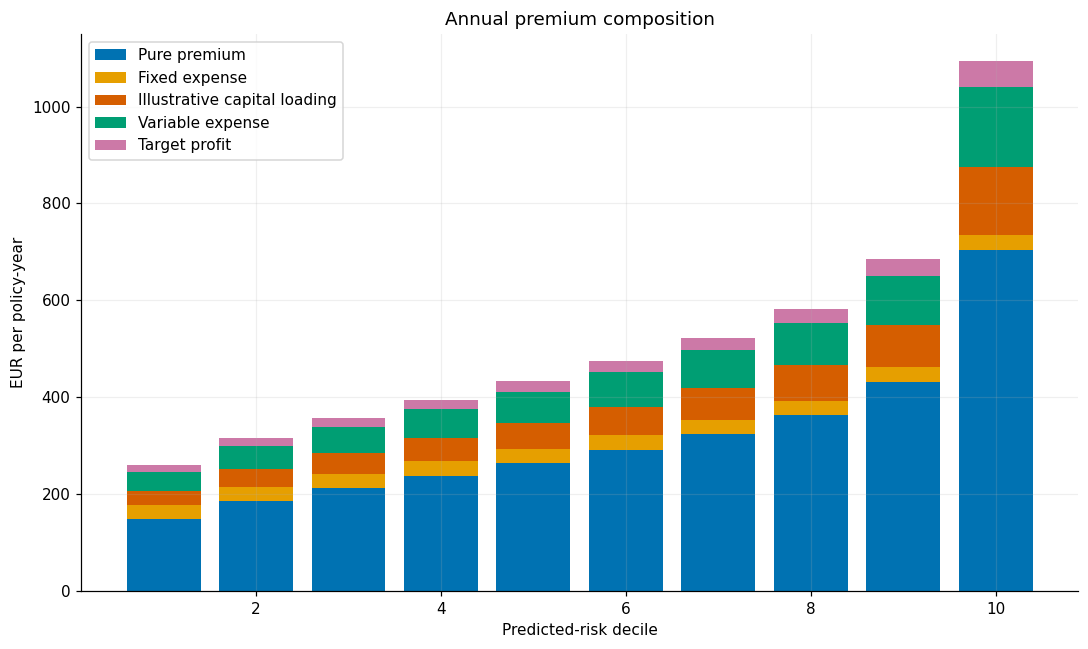

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
x = cal_table['decile']
bottom = np.zeros(len(cal_table))
for col, label, color in [
    ('pure_premium', 'Pure premium', 'C0'),
    ('fixed_expense', 'Fixed expense', 'C1'),
    ('capital_loading', 'Illustrative capital loading', 'C3'),
    ('variable_expense', 'Variable expense', 'C2'),
    ('target_profit', 'Target profit', 'C4'),
]:
    ax.bar(x, cal_table[col], bottom=bottom, label=label, color=color)
    bottom += cal_table[col].to_numpy()

ax.set_xlabel('Predicted-risk decile'); ax.set_ylabel('EUR per policy-year')
ax.set_title('Annual premium composition')
ax.legend()
plt.tight_layout(); plt.show()

### Capital-loading sensitivity

Reprice the test-set book at k = 0–2%, using observed exposure weights.

In [9]:
K_GRID = [0.0, 0.005, 0.010, 0.015, 0.020]
exposure_w = cal_table['total_exposure'].to_numpy()
pp = cal_table['pure_premium'].to_numpy()
rows = []
for k in K_GRID:
    load = pm.capital_loading_pro_rata(pp, portfolio_var995, portfolio_mean, k)
    assump_k = pm.PremiumAssumptions(ASSUMPTIONS.fixed_expense, ASSUMPTIONS.variable_expense_ratio,
                                     ASSUMPTIONS.target_profit_margin, k)
    gp = pm.gross_premium(pp, load, assump_k)
    book_gp = float((gp * exposure_w).sum())
    book_pp = float((pp * exposure_w).sum())
    book_exp = float(((ASSUMPTIONS.fixed_expense + gp * ASSUMPTIONS.variable_expense_ratio) * exposure_w).sum())
    rows.append({'k': k,
                 'loading_pct_of_pure_premium': 100 * float((load * exposure_w).sum()) / book_pp,
                 'avg_gross_premium_eur': book_gp / exposure_w.sum(),
                 'loss_ratio': book_pp / book_gp,
                 'combined_ratio_ex_profit': book_pp / book_gp + book_exp / book_gp})
capital_loading_sensitivity = pd.DataFrame(rows)
display(capital_loading_sensitivity.round(4))

implied_loading_6pct = 0.06 * capital_ratio
print(f"A 6% cost of capital applied to the undiversified one-policy-year K would give a loading of "
      f"{100*implied_loading_6pct:.0f}% of pure premium (k = 6%), far outside the grid above.")
assert capital_loading_sensitivity['avg_gross_premium_eur'].is_monotonic_increasing

,k,loading_pct_of_pure_premium,avg_gross_premium_eur,loss_ratio,combined_ratio_ex_profit
0,0.000,0.000,403.783,0.726,0.950
1,0.005,10.014,440.460,0.665,0.883
2,0.010,20.027,477.138,0.614,0.827
3,0.015,30.041,513.816,0.570,0.779
4,0.020,40.054,550.494,0.532,0.737


A 6% cost of capital applied to the undiversified one-policy-year K would give a loading of 120% of pure premium (k = 6%), far outside the grid above.


Premium increases with k by construction. The k = 1% case is illustrative; the data do not estimate this parameter or establish an equivalent diversification benefit.

## Quota share

Illustrative 25% quota share. Ceded premium = ceded expected loss plus a 20% loading, and the commission is deducted from expenses once. Rates are aggregated with actual exposure.

In [10]:
QS_SHARE = 0.25          # 25% quota share ceded
RI_LOADING = 0.20         # reinsurer prices ceded expected loss at a 20% loading
CEDING_COMMISSION = 0.25  # reinsurer reimburses 25% of ceded premium toward the cedant's acquisition costs

gross_premium_book = float((cal_table['gross_premium'] * cal_table['total_exposure']).sum())
pure_premium_book = float((cal_table['pure_premium'] * cal_table['total_exposure']).sum())
expense_book = float(((cal_table['fixed_expense'] + cal_table['variable_expense'])
                      * cal_table['total_exposure']).sum())

ceded_premium = QS_SHARE * pure_premium_book * (1 + RI_LOADING)
ceding_commission_received = CEDING_COMMISSION * ceded_premium
net_premium_book = gross_premium_book - ceded_premium

gross_losses_book = pure_premium_book   # expected losses = pure premium, by construction
net_losses_book = (1 - QS_SHARE) * gross_losses_book

gross_loss_ratio = pm.loss_ratio(gross_losses_book, gross_premium_book)
net_loss_ratio = pm.loss_ratio(net_losses_book, net_premium_book)

gross_expense_ratio = expense_book / gross_premium_book
net_expense_ratio = (expense_book - ceding_commission_received) / net_premium_book

gross_combined = pm.combined_ratio(gross_loss_ratio, gross_expense_ratio)
net_combined = pm.combined_ratio(net_loss_ratio, net_expense_ratio)

ri_compare = pd.DataFrame({
    'Basis': ['Gross', 'Net of 25% QS'],
    'Premium (EUR, observed exposure)': [gross_premium_book, net_premium_book],
    'Expected losses (EUR)': [gross_losses_book, net_losses_book],
    'Loss ratio': [gross_loss_ratio, net_loss_ratio],
    'Expense ratio': [gross_expense_ratio, net_expense_ratio],
    'Combined ratio': [gross_combined, net_combined],
})
ri_compare.round(4)

assert net_premium_book > 0
np.testing.assert_allclose(net_premium_book-net_losses_book-(expense_book-ceding_commission_received),
    gross_premium_book-gross_losses_book-expense_book+QS_SHARE*gross_losses_book-ceded_premium+ceding_commission_received,
    rtol=1e-12, atol=1e-6)
pricing_results = dict(currency='EUR', basis='actual held-out policy-year exposure',
    capital_loading=dict(k=ASSUMPTIONS.capital_loading_k, capital_ratio=float(capital_ratio),
        label='illustrative capital loading (assumed scaling, not Solvency II Risk Margin)',
        sensitivity=capital_loading_sensitivity.to_dict('records')),
    validation=validation.to_dict('records'), ratios=ri_compare.to_dict('records'),
    mean_annual_pure_premium=float(np.average(pure_prem_test, weights=test.Exposure)))
json.dump(pricing_results, open(result_path('pricing_results.json'),'w'), indent=2)
display(ri_compare.round(3))

,Basis,"Premium (EUR, observed exposure)",Expected losses (EUR),Loss ratio,Expense ratio,Combined ratio
0,Gross,"42,700,119.064","26,223,537.351",0.614,0.213,0.827
1,Net of 25% QS,"34,833,057.859","19,667,653.013",0.565,0.204,0.769


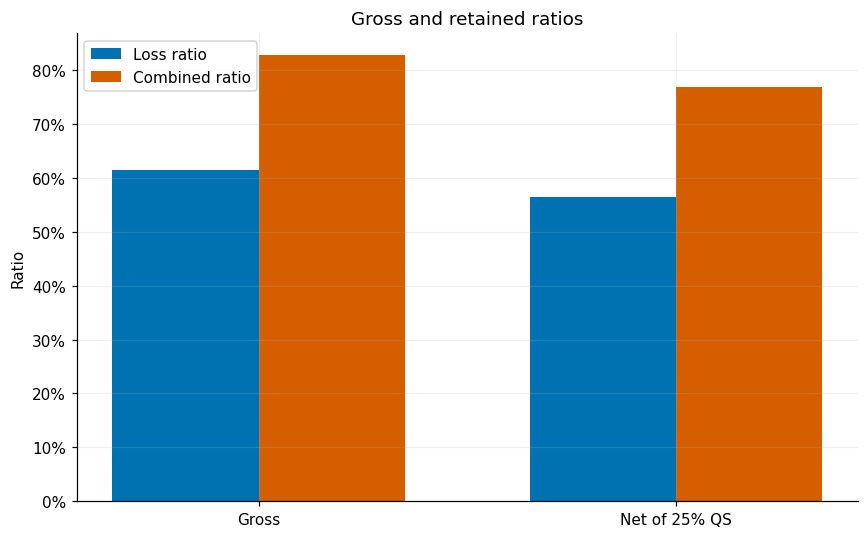

In [11]:
from matplotlib.ticker import PercentFormatter
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, ri_compare['Loss ratio'], width, label='Loss ratio', color='C0')
ax.bar(x + width/2, ri_compare['Combined ratio'], width, label='Combined ratio', color='C3')
ax.set_xticks(x); ax.set_xticklabels(ri_compare['Basis'])
ax.set_ylabel('Ratio')
ax.set_title('Gross and retained ratios')
ax.legend()
ax.yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout(); plt.show()

Combined ratio is 82.70% gross and 76.91% net of the quota share at k = 1%. Both depend on the assumed treaty price, commission and k. The net result reconciles to gross result + ceded losses − ceded premium + commission.

## Notes

- Count predictions are scored on held-out policies only.
- Pure premium and fixed expenses are per policy-year.
- The combined ratio excludes the profit target.
- Severity and treaty terms are simplified.

In [12]:
record_results('pricing_results.json')